<a href="https://colab.research.google.com/github/julmiha25-sys/Python/blob/main/%D0%98%D0%BD%D1%84%D0%BE%D1%80%D0%BC%D0%B0%D1%86%D0%B8%D0%BE%D0%BD%D0%BD%D0%B0%D1%8F_%D0%B1%D0%B5%D0%B7%D0%BE%D0%BF%D0%B0%D1%81%D0%BD%D0%BE%D1%81%D1%82%D1%8C/%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D0%B6%D0%B8%D0%B7%D0%BD%D0%B5%D0%BD%D0%BD%D0%BE%D0%B3%D0%BE_%D1%86%D0%B8%D0%BA%D0%BB%D0%B0_%D1%81%D0%B5%D1%80%D1%82%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%82%D0%BE%D0%B2_%D0%9A%D1%80%D0%B8%D0%BF%D1%82%D0%BE%D0%9F%D1%80%D0%BE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

АНАЛИЗ СЕРТИФИКАТОВ КРИПТОПРО

📊 СТАТУС СЕРТИФИКАТОВ:
   Истек: 14
   Действителен: 13
   Истекает (<30 дней): 1

СРОЧНО ЗАМЕНИТЬ (1 шт.):
   • "АО ""ТЭМЗ""" — истекает 27.04.2026 (через 26 дн.)

ОРГАНИЗАЦИИ С СЕРТИФИКАТАМИ:
   • Adobe Systems: 8
   • "АО ""ТЭМЗ""": 5
   • TCDE: 2
   • TEMZ: 1
   • "АКЦИОНЕРНОЕ ОБЩЕСТВО ""ТРОИЦКИЙ ЭЛЕКТРОМЕХАНИЧЕСКИЙ ЗАВОД""": 1


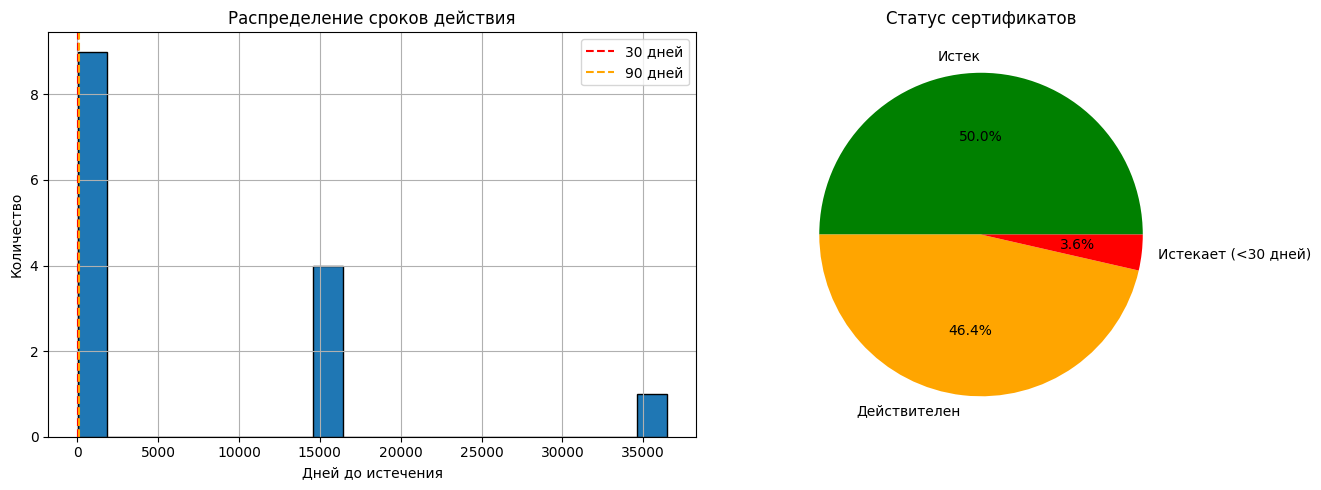


ПЛАН ЗАМЕНЫ НА БЛИЖАЙШИЕ МЕСЯЦЫ:
   Месяц 1: 1 сертификатов
   Месяц 2: 1 сертификатов
   Месяц 3: 1 сертификатов

ИСТЕКШИЕ СЕРТИФИКАТЫ (14 шт.):
   • "АО ""ТЭМЗ""" — истек 28.02.2025 (на 397 дн.)
   • Adobe Content Certificate 10-5 — истек 18.08.2025 (на 226 дн.)


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
# Загрузка данных
df = pd.read_csv('certificates.csv')
# Преобразование даты
df['NotAfter'] = pd.to_datetime(df['NotAfter'], format='%d.%m.%Y %H:%M:%S', errors='coerce')
# Текущая дата
today = datetime.now()
# 1. Срок действия сертификатов
df['days_left'] = (df['NotAfter'] - today).dt.days
print("АНАЛИЗ СЕРТИФИКАТОВ КРИПТОПРО")
# 2. Статус сертификатов
df['status'] = df['days_left'].apply(lambda x:
    'Истек' if x < 0 else
    'Истекает (<30 дней)' if x < 30 else
    'Истекает (<90 дней)' if x < 90 else
    'Действителен')
status_counts = df['status'].value_counts()
print("\n📊 СТАТУС СЕРТИФИКАТОВ:")
for status, count in status_counts.items():
    print(f"   {status}: {count}")
# 3. Сертификаты на замену
expiring_soon = df[df['days_left'].between(0, 30)]
if len(expiring_soon) > 0:
    print(f"\nСРОЧНО ЗАМЕНИТЬ ({len(expiring_soon)} шт.):")
    for _, row in expiring_soon.iterrows():
        org = row['Subject'].split('CN=')[-1].split(',')[0][:50]
        print(f"   • {org} — истекает {row['NotAfter'].strftime('%d.%m.%Y')} (через {row['days_left']} дн.)")
else:
    print("\nСертификатов, требующих срочной замены, нет")
# 4. Кто выдан (организации)
df['Organization'] = df['Subject'].str.extract(r'O=(.*?)(?:,|$)')
org_counts = df['Organization'].value_counts().head(10)
print("\nОРГАНИЗАЦИИ С СЕРТИФИКАТАМИ:")
for org, count in org_counts.items():
    print(f"   • {org}: {count}")
# 5. Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Гистограмма сроков
df[df['days_left'] > 0]['days_left'].hist(bins=20, ax=axes[0], edgecolor='black')
axes[0].axvline(30, color='red', linestyle='--', label='30 дней')
axes[0].axvline(90, color='orange', linestyle='--', label='90 дней')
axes[0].set_title('Распределение сроков действия')
axes[0].set_xlabel('Дней до истечения')
axes[0].set_ylabel('Количество')
axes[0].legend()
# Круговая диаграмма статусов
colors = ['green', 'orange', 'red', 'gray']
axes[1].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', colors=colors[:len(status_counts)])
axes[1].set_title('Статус сертификатов')
plt.tight_layout()
plt.show()
# 6. Прогноз замен
print("\nПЛАН ЗАМЕНЫ НА БЛИЖАЙШИЕ МЕСЯЦЫ:")
for month in range(1, 4):
    end_date = today + timedelta(days=30*month)
    expiring = df[(df['days_left'] > 0) & (df['days_left'] <= 30*month)]
    print(f"   Месяц {month}: {len(expiring)} сертификатов")
# 7. Критические (уже истекшие)
expired = df[df['days_left'] < 0]
if len(expired) > 0:
    print(f"\nИСТЕКШИЕ СЕРТИФИКАТЫ ({len(expired)} шт.):")
    for _, row in expired[:2].iterrows():
        org = row['Subject'].split('CN=')[-1].split(',')[0][:50]
        print(f"   • {org} — истек {row['NotAfter'].strftime('%d.%m.%Y')} (на {abs(row['days_left'])} дн.)")
    '''
    for _, row in expired.iterrows():
        org = row['Subject'].split('CN=')[-1].split(',')[0][:50]
        print(f"   • {org} — истек {row['NotAfter'].strftime('%d.%m.%Y')} (на {abs(row['days_left'])} дн.)")
    '''
else:
    print("\nИстекших сертификатов нет")